# 8. PMD calling insulation

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}clustering/merged/group_meta.tsv'`  ·  _metadata_
- `f'{indir}merged_allc/cluster_donor.mcds'`  ·  _sc/pseudobulk mC (allc)_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from concurrent.futures import ProcessPoolExecutor, as_completed

import pysam
import anndata

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'


In [3]:
group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
# group_meta = group_meta[['L2_any', 'L1', 'count']]
group_meta['L1_annot'] = group_meta['L1_annot'].str.replace(' ','-').str.replace('/','_')
annot2L1 = group_meta[['L1','L1_annot']].set_index('L1_annot')['L1'].to_dict()
L1annot = group_meta[['L1','L1_annot']].set_index('L1')['L1_annot'].to_dict()


In [4]:
from ALLCools.mcds import MCDS

mcds = MCDS.open(f'{indir}merged_allc/cluster_donor.mcds', var_dim='chrom1k')
mcds

<xarray.MCDS> Size: 93GB
Dimensions:        (cell: 940, chrom1k: 3088298, count_type: 2, mc_type: 4)
Coordinates:
  * cell           (cell) <U16 60kB 'c0-c0-PT-1JKYN' ... 'c9-c9-STL003'
  * chrom1k        (chrom1k) <U12 148MB 'chr1_0' 'chr1_1' ... 'chrY_57227'
    chrom1k_chrom  (chrom1k) <U5 62MB ...
    chrom1k_end    (chrom1k) int64 25MB ...
    chrom1k_start  (chrom1k) int64 25MB ...
  * count_type     (count_type) <U3 24B 'mc' 'cov'
  * mc_type        (mc_type) <U3 48B 'CAN' 'CCN' 'CGN' 'CTN'
Data variables:
    chrom1k_da     (cell, chrom1k, mc_type, count_type) uint32 93GB dask.array<chunksize=(1, 386038, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom1k

In [5]:
mcds = mcds.assign_coords(L1=('cell', group_meta.loc[mcds.get_index('cell'), 'L1']))
mcds = mcds.groupby('L1').sum()


In [6]:
# mcds = mcds.assign_coords(chrom10k=('chrom1k', bin_df['chrom1k']))
mcds = mcds.sel({'mc_type':'CGN'})
mcds = MCDS(mcds, obs_dim='L1', var_dim='chrom1k')
mcds

<xarray.MCDS> Size: 2GB
Dimensions:        (chrom1k: 3088298, count_type: 2, L1: 35)
Coordinates:
  * chrom1k        (chrom1k) <U12 148MB 'chr1_0' 'chr1_1' ... 'chrY_57227'
    chrom1k_chrom  (chrom1k) <U5 62MB 'chr1' 'chr1' 'chr1' ... 'chrY' 'chrY'
    chrom1k_end    (chrom1k) int64 25MB 1000 2000 3000 ... 57227000 57227415
    chrom1k_start  (chrom1k) int64 25MB 0 1000 2000 ... 57226000 57227000
  * count_type     (count_type) <U3 24B 'mc' 'cov'
    mc_type        <U3 12B 'CGN'
  * L1             (L1) object 280B 'c0' 'c1' 'c10' 'c11' ... 'c7' 'c8' 'c9'
Data variables:
    chrom1k_da     (L1, chrom1k, count_type) float64 2GB dask.array<chunksize=(1, 386038, 1), meta=np.ndarray>
Attributes:
    obs_dim:  L1
    var_dim:  chrom1k

In [7]:
exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds = mcds.remove_chromosome(exclude_chromosome)


213286 chrom1k features in ['chrX', 'chrY', 'chrM', 'chrL'] removed.


In [8]:
mcds['chrom1k_da_frac'] = mcds['chrom1k_da'].sel({'count_type':'mc'}) / mcds['chrom1k_da'].sel({'count_type':'cov'})
# .add_mc_frac(normalize_per_cell=False)


In [9]:
bin_df = mcds[['chrom1k_chrom', 'chrom1k_start', 'chrom1k_end']].to_pandas()


In [10]:
bin_df = bin_df[['chrom1k_chrom','chrom1k_start','chrom1k_end']]
bin_df.columns = ['chrom', 'start', 'end']

In [11]:
data = mcds['chrom1k_da_frac'].to_pandas().fillna(0)
print(data.shape)

(35, 2875012)


In [12]:
from pybedtools import BedTool

black_list_path = '/large_experiments/zhoulab/ref/blacklist/hg38-blacklist.v2.bed.gz'
alt_allele_path = f'{REF_ROOT}/hg38/fasta/hg38.altseq.bed'

def remove_region(black_list_path):
    feature_bed = BedTool.from_dataframe(bin_df)
    black_list_bed = BedTool(black_list_path)
    black_feature = feature_bed.intersect(black_list_bed, f=0.2, wa=True)
    black_feature_index = black_feature.to_dataframe().set_index(["chrom", "start", "end"]).index
    black_feature_id = pd.Index(
        bin_df.reset_index()
        .set_index(["chrom", "start", "end"])
        .loc[black_feature_index][bin_df.index.name]
    )
    print(black_feature_id.shape[0])
    return black_feature_id


In [13]:
black_feature_id = remove_region(black_list_path)
alt_feature_id = remove_region(alt_allele_path)


187135
137403


In [14]:
data.loc[:, data.columns.isin(black_feature_id) | data.columns.isin(alt_feature_id)] = 0

In [15]:
import math
from scipy.stats import ranksums

ws = 25
res = 1000
vmin = 0.05
pvmax = 1

def callpmd_worker(chrom, ct):
    chrfilter = (bin_df['chrom']==chrom)
    datachr = data.loc[ct, chrfilter].values[np.argsort(bin_df.loc[chrfilter, 'start'])].copy()
    # datachr = np.abs(datachr - 0.5) + 0.5
    conv = np.convolve(datachr, np.ones(ws), mode='valid') ##chrlen-ws+1; i is average of datachr[i:(i+ws)]
    diff = np.abs(conv[:-ws] - conv[ws:]) ##chrlen-2ws+1; 0 -> datachr[ws], i is diff between datachr[i:(i+ws)] and datachr[(i+ws):(i+2ws)]
    print(diff.shape[0], datachr.shape[0])

    s, t = 0, diff.shape[0]
    turn = [s]
    while s<(t-2):
        last = math.hypot(1, diff[s+1]-diff[s]) ## initialize with 2 points
        for k in range(s+2,t):
            slope = (diff[k] - diff[s]) / (k - s)
            l = np.abs([diff[i] - diff[s] - slope*(i-s) for i in range(s+1, k)]).sum()
            tmp = math.hypot(k-s, diff[k]-diff[s]) - l
            if (tmp<last):
                s = k - 1
                last = math.hypot(1, diff[s+1]-diff[s])
                turn.append(s)
                break
            else:
                last = tmp
        if k>=(t-1):
            s = k
            turn.append(s)

    turn = np.array(turn) ##position in diff, 0 -> datachr[ws]
    pv = np.array([True] + [ranksums(datachr[xx:(xx+ws)], datachr[(xx+ws):(xx+2*ws)])[1] for xx in turn[1:-1]] + [True]) 
    localmax_filter = np.logical_and(diff[turn[1:-1]]>diff[turn[:-2]], diff[turn[1:-1]]>diff[turn[2:]])
    localmax_filter = [True] + localmax_filter.tolist() + [True] ## shape n_turn
    localmax = turn[np.logical_and(pv<pvmax , localmax_filter)]
    print(localmax.shape)
    cumsum = np.cumsum(datachr)
    segave = (cumsum[localmax[1:]+ws] - cumsum[localmax[:-1]+ws]) / (localmax[1:] - localmax[:-1]) ## shape n_localmax-1, i is ave mcg between localmax[i] and localmax[i+1]
    selseg = np.logical_and(segave<vmax, segave>vmin)
    pmdstart = localmax[1:-1][np.logical_and(~selseg[:-1], selseg[1:])] ## index in localmax
    if selseg[0]:
        pmdstart = [localmax[0]] + list(pmdstart)
    pmdend = localmax[1:-1][np.logical_and(selseg[:-1], ~selseg[1:])] ## index in localmax
    if selseg[-1]:
        pmdend = list(pmdend) + [localmax[-1]]
    pmdchr = (pd.DataFrame(np.array([pmdstart, pmdend]), index=['start', 'end']).T) + ws
    pmdchr['ave'] = (cumsum[pmdchr['end']] - cumsum[pmdchr['start']]) / (pmdchr['end'] - pmdchr['start'])
    pmdchr[['start', 'end']] = pmdchr[['start', 'end']] * res
    pmdchr['chrom'] = chrom
    return datachr, diff, turn, localmax, pmdchr


In [16]:
datatmp = data.loc[:, ~(data.columns.isin(black_feature_id) | data.columns.isin(alt_feature_id))]
cgmean = datatmp.mean(axis=1)
cgmedian = datatmp.median(axis=1)

# cgmean = np.abs(datatmp - 0.5).mean(axis=1) + 0.5
# cgmedian = np.abs(datatmp - 0.5).median(axis=1) + 0.5

<Axes: ylabel='Count'>

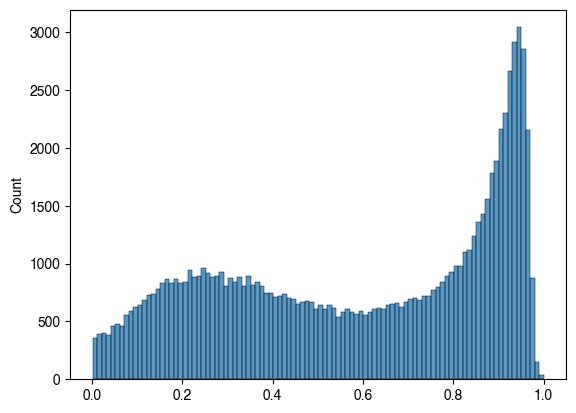

In [63]:
ct = 'c2'
tmp = np.random.choice(data.loc[ct].values, 100000, False)
sns.histplot(tmp[tmp>0], bins=100)


<Axes: ylabel='Count'>

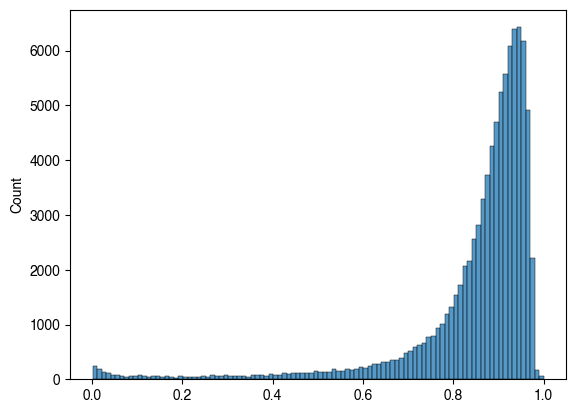

In [67]:
ct = 'c0'
tmp = np.random.choice(data.loc[ct].values, 100000, False)
sns.histplot(tmp[tmp>0], bins=100)


<Axes: ylabel='Count'>

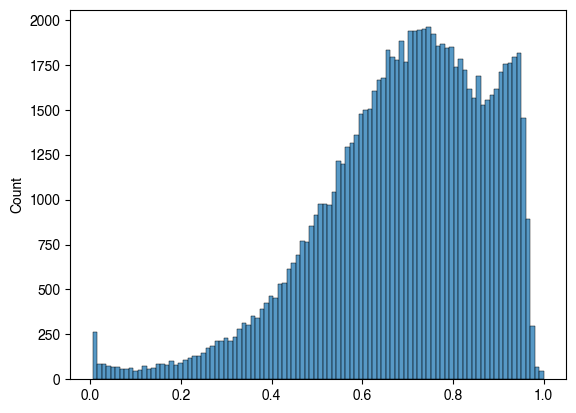

In [69]:
ct = 'c7'
tmp = np.random.choice(data.loc[ct].values, 100000, False)
sns.histplot(tmp[tmp>0], bins=100)


<Axes: ylabel='Count'>

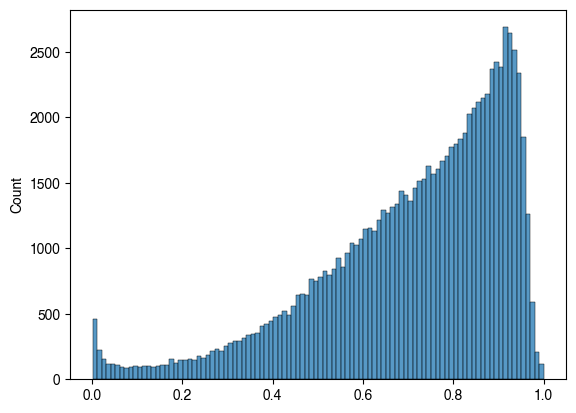

In [62]:
ct = 'c22'
tmp = np.random.choice(data.loc[ct].values, 100000, False)
sns.histplot(tmp[tmp>0], bins=100)


In [17]:
from concurrent.futures import ProcessPoolExecutor, as_completed

ct = 'c0'
vmax = cgmedian.loc[ct]
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for chrom in bin_df['chrom'].unique():
        future = executor.submit(
            callpmd_worker,
            chrom=chrom,
            ct=ct,
        )
        futures[future] = chrom

    pmd = []
    for future in as_completed(futures):
        chrom = futures[future]
        datachr, diff, turn, localmax, pmdchr = future.result()
        pmd.append(pmdchr)
        print(f'{chrom} finished')
        

248908
 248957133749135038  133798135087

133227114316  133276114365

106995 107044
101943 10199290290
 90339
83209 83258
80325 80374
5856958618 
64396
 64445242145 46661242194
 46710
50770 50819
198247
 198296190166 190215
181490 181539
170757 170806
159297 159346
138346 138395
145090 145139
(2898,)
chr20 finished
(5955,)
chr10 finished
(2921,)
(3569,)
chr19 finished
chr17 finished
(6252,)
chr11 finished
(8417,)
chr4 finished
(6339,)
chr8 finished
(6086,)
chr12 finished
(3221,)
(6957,)
chr18 finished
chr7 finished
(7833,)
chr5 finished
(7556,)
(1549,)
chr6 finished
chr21 finished
(8814,)
chr3 finished
(10391,)
chr2 finished
(3611,)
chr16 finished
(1709,)
chr22 finished
(4273,)
chr13 finished
(3313,)
chr15 finished
(5144,)
chr9 finished
(3892,)
chr14 finished
(10917,)
chr1 finished


In [74]:
vmax

0.8721770503039625

In [18]:
pmd = pd.concat(pmd, axis=0)[['chrom', 'start', 'end', 'ave']]
pmd.to_csv(f'pmd_calling/{ct}_pmd_ws{ws}_nopv_median.bed', sep='\t', index=False, header=False)


In [87]:
chrom, start, end = 'chr1', 7000000, 8500000
res = 1000


In [78]:
ct = 'c0'
vmax = cgmean.loc[ct]
datachr, diff, turn, localmax, pmdchr = callpmd_worker(ct=ct, chrom='chr1')


248908 248957
(2521,)


In [85]:
localmax_filter = np.logical_and(diff[turn[1:-1]]>diff[turn[:-2]], diff[turn[1:-1]]>diff[turn[2:]])
localmax_filter = [True] + localmax_filter.tolist() + [True] ## shape n_turn
localmax = turn[localmax_filter]
print(localmax.shape)

cumsum = np.cumsum(datachr)
segave = (cumsum[localmax[1:]+ws] - cumsum[localmax[:-1]+ws]) / (localmax[1:] - localmax[:-1]) ## shape n_localmax-1, i is ave mcg between localmax[i] and localmax[i+1]
selseg = np.logical_and(segave<vmax, segave>vmin)
pmdstart = localmax[1:-1][np.logical_and(~selseg[:-1], selseg[1:])] ## index in localmax
if selseg[0]:
    pmdstart = [localmax[0]] + list(pmdstart)
pmdend = localmax[1:-1][np.logical_and(selseg[:-1], ~selseg[1:])] ## index in localmax
if selseg[-1]:
    pmdend = list(pmdend) + [localmax[-1]]
pmdchr = (pd.DataFrame(np.array([pmdstart, pmdend]), index=['start', 'end']).T) + ws
pmdchr['ave'] = (cumsum[pmdchr['end']] - cumsum[pmdchr['start']]) / (pmdchr['end'] - pmdchr['start'])
pmdchr[['start', 'end']] = pmdchr[['start', 'end']] * res
pmdchr['chrom'] = chrom


(7637,)


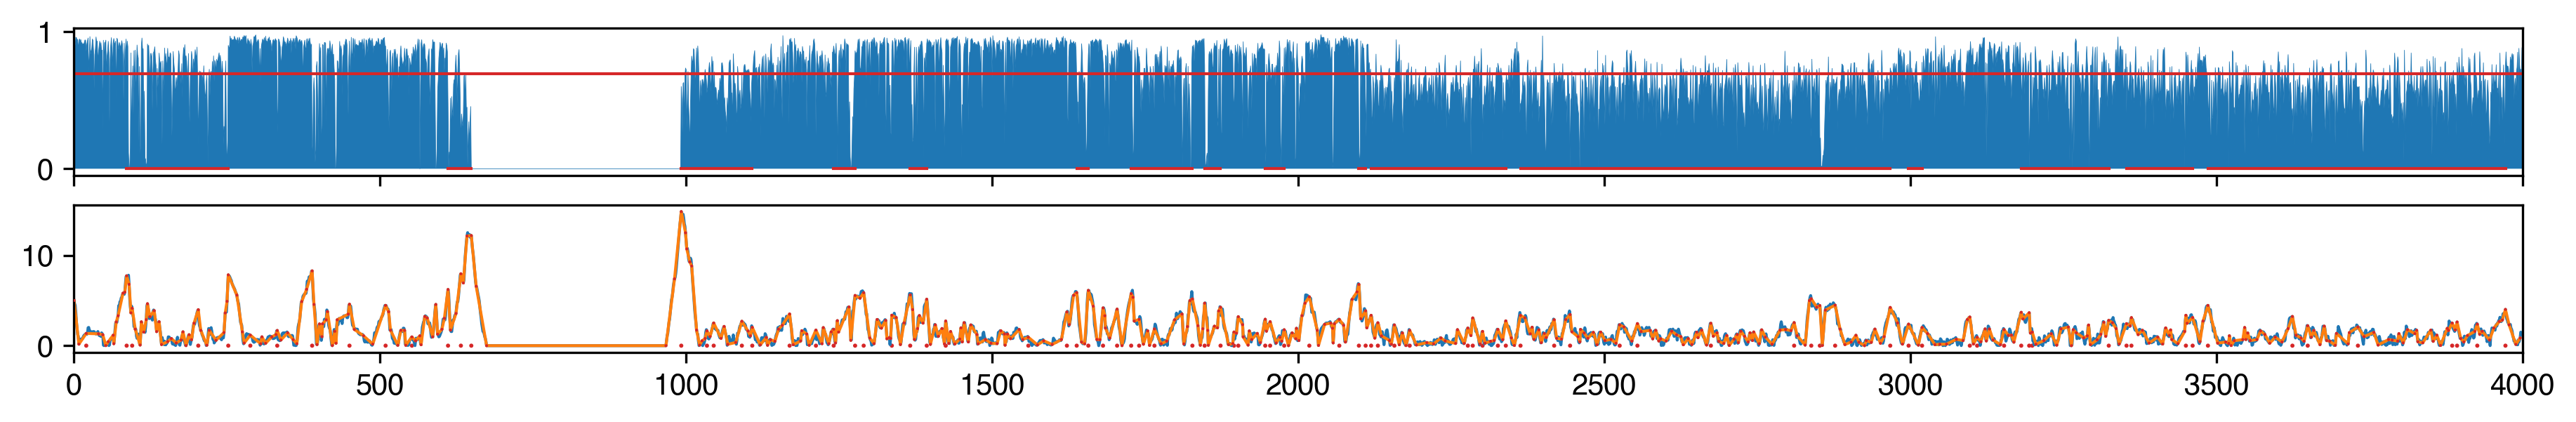

In [48]:
## c22 Aci
fig, axes = plt.subplots(2, 1, figsize=(15,2), dpi=300, sharex='all')

ax = axes[0]
tmp = datachr[(start//res):(end//res)]  ## 0 is datachr[start//res]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, linewidth=0.2)
ax.set_xlim([0, tmp.shape[0]])
ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor='C0', interpolate=True)
# ax.scatter(x[tmp<0.8], np.zeros((tmp<0.8).sum()), c='C3', s=1, edgecolor='none', rasterized=True)
ax.plot([x[0], x[-1]], [vmax, vmax], 'C3', linewidth=1)
pmdtmp = (pmdchr.loc[(pmdchr['end']>start) & (pmdchr['start']<end), ['start', 'end']].values - start) // res
for xx,yy in pmdtmp:
    ax.plot([xx, yy], [0, 0], 'C3', linewidth=1)

ax = axes[1]
tmp = np.zeros(datachr.shape[0])
tmp[ws:(-ws+1)] = np.abs(diff) ## ws is diff[0], is diff between datachr[0:ws] and datachr[ws:2ws], 0->datachr[0]
tmp = tmp[(start//res):(end//res)]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, 'C0', linewidth=1)

regionfilter = np.logical_and((turn+ws)>=start//res, (turn+ws)<end//res) ## shape n_turn
turntmp = turn[regionfilter] ## position in diff, 0 -> datachr[ws]
ax.plot(turntmp - start//res + ws, diff[turntmp], 'C1', linewidth=1)

ax.scatter(turntmp - start//res + ws, diff[turntmp], c='C3', s=1, zorder=100, edgecolor='none', rasterized=True)

regionfilter = np.logical_and((localmax+ws)>=start//res, (localmax+ws)<end//res) ## shape n_turn
tmp = localmax[regionfilter]
ax.scatter(tmp - start//res + ws, np.zeros(tmp.shape), c='C3', s=2, edgecolor='none', rasterized=True)


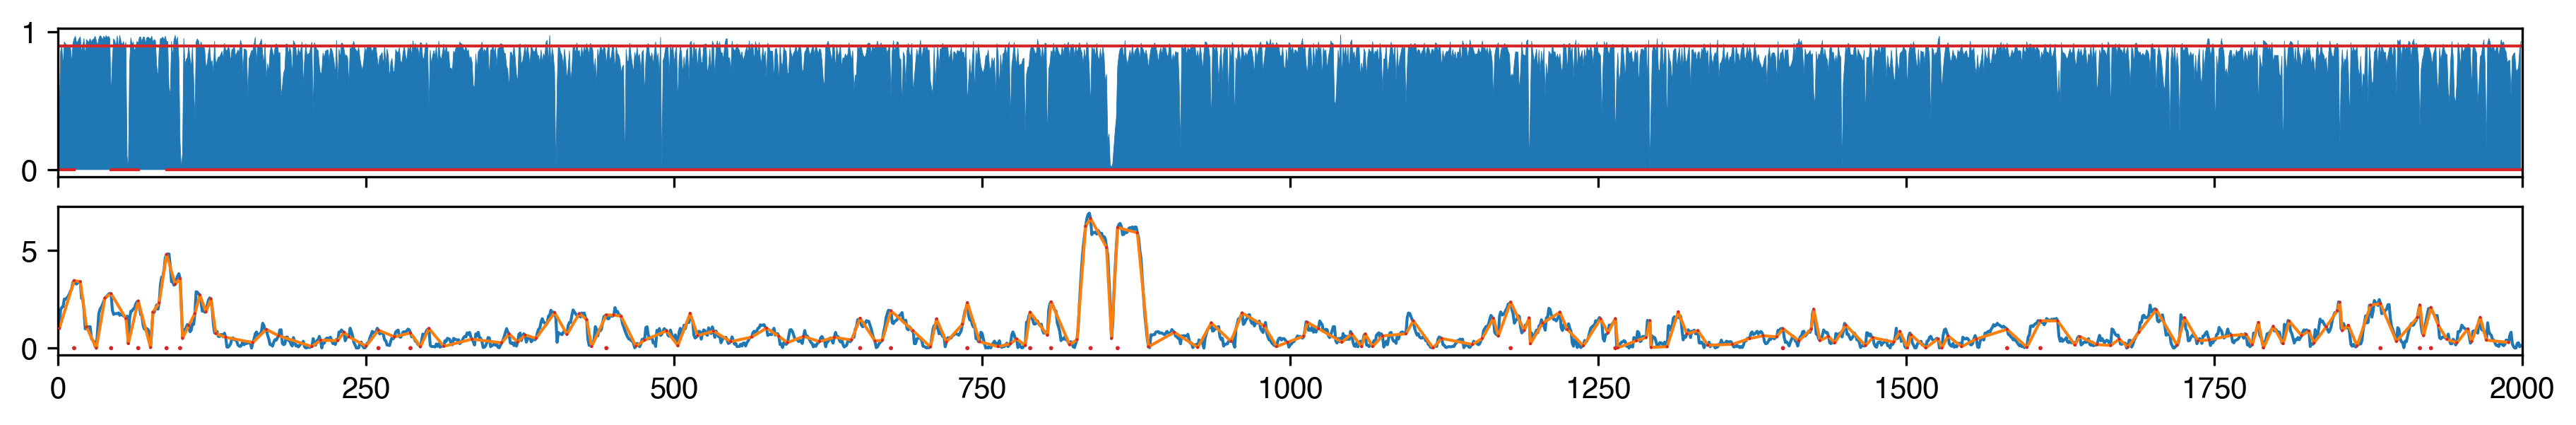

In [61]:
## c0 Tmem

fig, axes = plt.subplots(2, 1, figsize=(15,2), dpi=300, sharex='all')

ax = axes[0]
tmp = datachr[(start//res):(end//res)]  ## 0 is datachr[start//res]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, linewidth=0.2)
ax.set_xlim([0, tmp.shape[0]])
ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor='C0', interpolate=True)
# ax.scatter(x[tmp<0.8], np.zeros((tmp<0.8).sum()), c='C3', s=1, edgecolor='none', rasterized=True)
ax.plot([x[0], x[-1]], [vmax, vmax], 'C3', linewidth=1)
pmdtmp = (pmdchr.loc[(pmdchr['end']>start) & (pmdchr['start']<end), ['start', 'end']].values - start) // res
for xx,yy in pmdtmp:
    ax.plot([xx, yy], [0, 0], 'C3', linewidth=1)

ax = axes[1]
tmp = np.zeros(datachr.shape[0])
tmp[ws:(-ws+1)] = np.abs(diff) ## ws is diff[0], is diff between datachr[0:ws] and datachr[ws:2ws], 0->datachr[0]
tmp = tmp[(start//res):(end//res)]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, 'C0', linewidth=1)

regionfilter = np.logical_and((turn+ws)>=start//res, (turn+ws)<end//res) ## shape n_turn
turntmp = turn[regionfilter] ## position in diff, 0 -> datachr[ws]
ax.plot(turntmp - start//res + ws, diff[turntmp], 'C1', linewidth=1)

ax.scatter(turntmp - start//res + ws, diff[turntmp], c='C3', s=1, zorder=100, edgecolor='none', rasterized=True)

regionfilter = np.logical_and((localmax+ws)>=start//res, (localmax+ws)<end//res) ## shape n_turn
tmp = localmax[regionfilter]
ax.scatter(tmp - start//res + ws, np.zeros(tmp.shape), c='C3', s=2, edgecolor='none', rasterized=True)


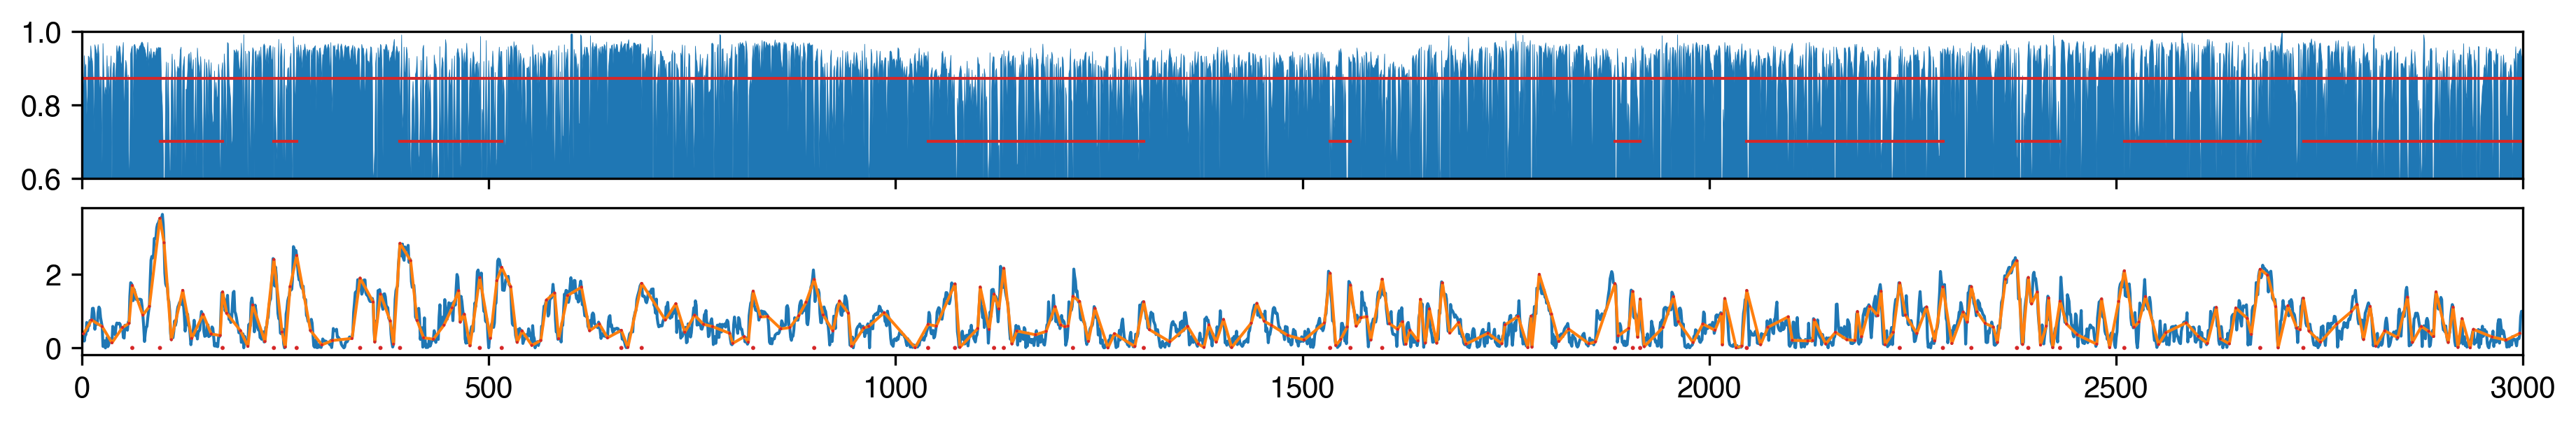

In [83]:
## c0 Tmem

ymin = 0.6
fig, axes = plt.subplots(2, 1, figsize=(15,2), dpi=300, sharex='all')

ax = axes[0]
tmp = datachr[(start//res):(end//res)]  ## 0 is datachr[start//res]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, linewidth=0.2)
ax.set_xlim([0, tmp.shape[0]])
ax.set_ylim([ymin, 1.0])
ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor='C0', interpolate=True)
# ax.scatter(x[tmp<0.8], np.zeros((tmp<0.8).sum()), c='C3', s=1, edgecolor='none', rasterized=True)
ax.plot([x[0], x[-1]], [vmax, vmax], 'C3', linewidth=1)
pmdtmp = (pmdchr.loc[(pmdchr['end']>start) & (pmdchr['start']<end), ['start', 'end']].values - start) // res
for xx,yy in pmdtmp:
    ax.plot([xx, yy], [ymin+0.1, ymin+0.1], 'C3', linewidth=1)

ax = axes[1]
tmp = np.zeros(datachr.shape[0])
tmp[ws:(-ws+1)] = np.abs(diff) ## ws is diff[0], is diff between datachr[0:ws] and datachr[ws:2ws], 0->datachr[0]
tmp = tmp[(start//res):(end//res)]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, 'C0', linewidth=1)

regionfilter = np.logical_and((turn+ws)>=start//res, (turn+ws)<end//res) ## shape n_turn
turntmp = turn[regionfilter] ## position in diff, 0 -> datachr[ws]
ax.plot(turntmp - start//res + ws, diff[turntmp], 'C1', linewidth=1)

ax.scatter(turntmp - start//res + ws, diff[turntmp], c='C3', s=1, zorder=100, edgecolor='none', rasterized=True)

regionfilter = np.logical_and((localmax+ws)>=start//res, (localmax+ws)<end//res) ## shape n_turn
tmp = localmax[regionfilter]
ax.scatter(tmp - start//res + ws, np.zeros(tmp.shape), c='C3', s=2, edgecolor='none', rasterized=True)


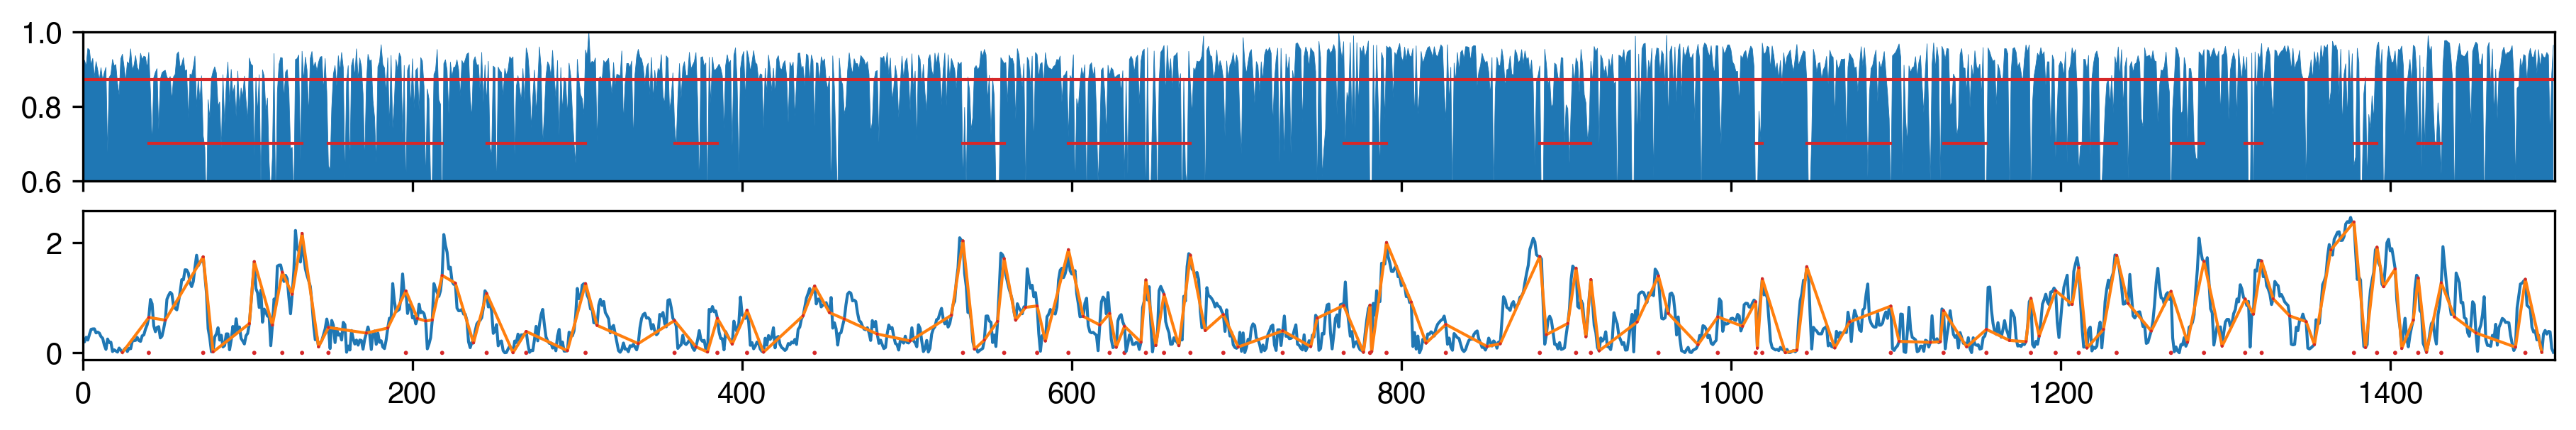

In [88]:
## c0 Tmem

ymin = 0.6
fig, axes = plt.subplots(2, 1, figsize=(15,2), dpi=300, sharex='all')

ax = axes[0]
tmp = datachr[(start//res):(end//res)]  ## 0 is datachr[start//res]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, linewidth=0.2)
ax.set_xlim([0, tmp.shape[0]])
ax.set_ylim([ymin, 1.0])
ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor='C0', interpolate=True)
# ax.scatter(x[tmp<0.8], np.zeros((tmp<0.8).sum()), c='C3', s=1, edgecolor='none', rasterized=True)
ax.plot([x[0], x[-1]], [vmax, vmax], 'C3', linewidth=1)
pmdtmp = (pmdchr.loc[(pmdchr['end']>start) & (pmdchr['start']<end), ['start', 'end']].values - start) // res
for xx,yy in pmdtmp:
    ax.plot([xx, yy], [ymin+0.1, ymin+0.1], 'C3', linewidth=1)

ax = axes[1]
tmp = np.zeros(datachr.shape[0])
tmp[ws:(-ws+1)] = np.abs(diff) ## ws is diff[0], is diff between datachr[0:ws] and datachr[ws:2ws], 0->datachr[0]
tmp = tmp[(start//res):(end//res)]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, 'C0', linewidth=1)

regionfilter = np.logical_and((turn+ws)>=start//res, (turn+ws)<end//res) ## shape n_turn
turntmp = turn[regionfilter] ## position in diff, 0 -> datachr[ws]
ax.plot(turntmp - start//res + ws, diff[turntmp], 'C1', linewidth=1)

ax.scatter(turntmp - start//res + ws, diff[turntmp], c='C3', s=1, zorder=100, edgecolor='none', rasterized=True)

regionfilter = np.logical_and((localmax+ws)>=start//res, (localmax+ws)<end//res) ## shape n_turn
tmp = localmax[regionfilter]
ax.scatter(tmp - start//res + ws, np.zeros(tmp.shape), c='C3', s=2, edgecolor='none', rasterized=True)


In [16]:
chrfilter = (bin_df['chrom']==chrom)
datachr = data.loc['c2', chrfilter].values[np.argsort(bin_df.loc[chrfilter, 'start'])]
datachr.shape ##chrlen

(248957,)

In [72]:
ws = 25
conv = np.convolve(datachr, np.ones(ws), mode='valid') ##chrlen-ws+1; i is average of datachr[i:(i+ws)]
diff = np.abs(conv[:-ws] - conv[ws:]) ##chrlen-2ws+1; 0 -> datachr[ws], i is diff between datachr[i:(i+ws)] and datachr[(i+ws):(i+2ws)]
print(diff.shape[0], datachr.shape[0])


248908 248957


In [73]:
import math

s, t = 0, diff.shape[0]
turn = [s]
while s<(t-2):
    last = math.hypot(1, diff[s+1]-diff[s]) ## initialize with 2 points
    for k in range(s+2,t):
        slope = (diff[k] - diff[s]) / (k - s)
        l = np.abs([diff[i] - diff[s] - slope*(i-s) for i in range(s+1, k)]).sum()
        tmp = math.hypot(k-s, diff[k]-diff[s]) - l
        if (tmp<last):
            s = k - 1
            last = math.hypot(1, diff[s+1]-diff[s])
            turn.append(s)
            break
        else:
            last = tmp
    if k>=(t-1):
        s = k
        turn.append(s)
        
turn = np.array(turn) ##position in diff, 0 -> datachr[ws]


In [74]:
from scipy.stats import ranksums

pv = np.array([True] + [ranksums(datachr[xx:(xx+ws)], datachr[(xx+ws):(xx+2*ws)])[1] for xx in turn[1:-1]] + [True]) 
##shape n_turn, position in diff


In [ ]:
# from sklearn.metrics import roc_auc_score
# label = np.repeat([1, 0], ws)
# roc = np.array([roc_auc_score(label, datachr[xx:(xx+2*ws)]) for xx in turn])
# roc = np.abs(roc - 0.5) + 0.5


In [43]:
# print((pv<0.05).sum(), (roc>0.8).sum())


16237 2351


In [75]:
localmax_filter = np.logical_and(diff[turn[1:-1]]>diff[turn[:-2]], diff[turn[1:-1]]>diff[turn[2:]])
localmax_filter = [True] + localmax_filter.tolist() + [True]
## shape n_turn

In [76]:
localmax = turn[np.logical_and(pv<0.05 , localmax_filter)]
print(localmax.shape)

(6043,)


In [82]:
cumsum = np.cumsum(datachr)
segave = (cumsum[localmax[1:]+ws] - cumsum[localmax[:-1]+ws]) / (localmax[1:] - localmax[:-1]) ## shape n_localmax-1, i is ave mcg between localmax[i] and localmax[i+1]
selseg = np.logical_and(segave<0.6, segave>0.05)
pmdstart = localmax[1:-1][np.logical_and(~selseg[:-1], selseg[1:])] ## index in localmax
if selseg[0]:
    pmdstart = [localmax[0]] + list(pmdstart)
pmdend = localmax[1:-1][np.logical_and(selseg[:-1], ~selseg[1:])] ## index in localmax
if selseg[-1]:
    pmdend = list(pmdend) + [localmax[-1]]
pmdchr = (pd.DataFrame(np.array([pmdstart, pmdend]), index=['start', 'end']).T) + ws
pmdchr['ave'] = (cumsum[pmdchr['end']] - cumsum[pmdchr['start']]) / (pmdchr['end'] - pmdchr['start'])
pmdchr[['start', 'end']] = pmdchr[['start', 'end']] * res
pmdchr['chrom'] = chrom


In [64]:
# regionfilter = np.logical_and((localmax+ws)>=start//res, (localmax+ws)<end//res) ## shape n_turn
# tmp = localmax[regionfilter]
# print(tmp.shape)

(92,)


In [65]:
# segave[np.logical_and((localmax[1:]+ws)<(end//res), (localmax[:-1]+ws)>(start//res))].shape

(91,)

In [66]:
# segave[np.logical_and((localmax[1:]+ws)<(end//res), (localmax[:-1]+ws)>(start//res))]

array([0.86691945, 0.76393213, 0.62904071, 0.74393731, 0.63548146,
       0.57067832, 0.45432117, 0.70633545, 0.55417306, 0.70502041,
       0.49479905, 0.9189361 , 0.64724778, 0.73136365, 0.90778496,
       0.86300378, 0.67149066, 0.85443526, 0.88669545, 0.68202107,
       0.83376149, 0.64871933, 0.62835571, 0.69355253, 0.22529099,
       0.12027773, 0.00283498, 0.2502402 , 0.24371085, 0.17317934,
       0.19858879, 0.17850632, 0.22659044, 0.17378252, 0.22002249,
       0.18948308, 0.31112004, 0.21691326, 0.64952498, 0.33585935,
       0.67996297, 0.64144055, 0.48144936, 0.34018157, 0.4567943 ,
       0.67436082, 0.3988807 , 0.72595724, 0.52098908, 0.65536264,
       0.53785211, 0.81115981, 0.68605071, 0.71456254, 0.65218947,
       0.84896192, 0.59646162, 0.26825542, 0.22245362, 0.26120621,
       0.23117544, 0.23094134, 0.17212232, 0.22193686, 0.20433093,
       0.18923458, 0.16001434, 0.30189557, 0.72796631, 0.81580418,
       0.45428955, 0.20551207, 0.25154526, 0.19230383, 0.21829

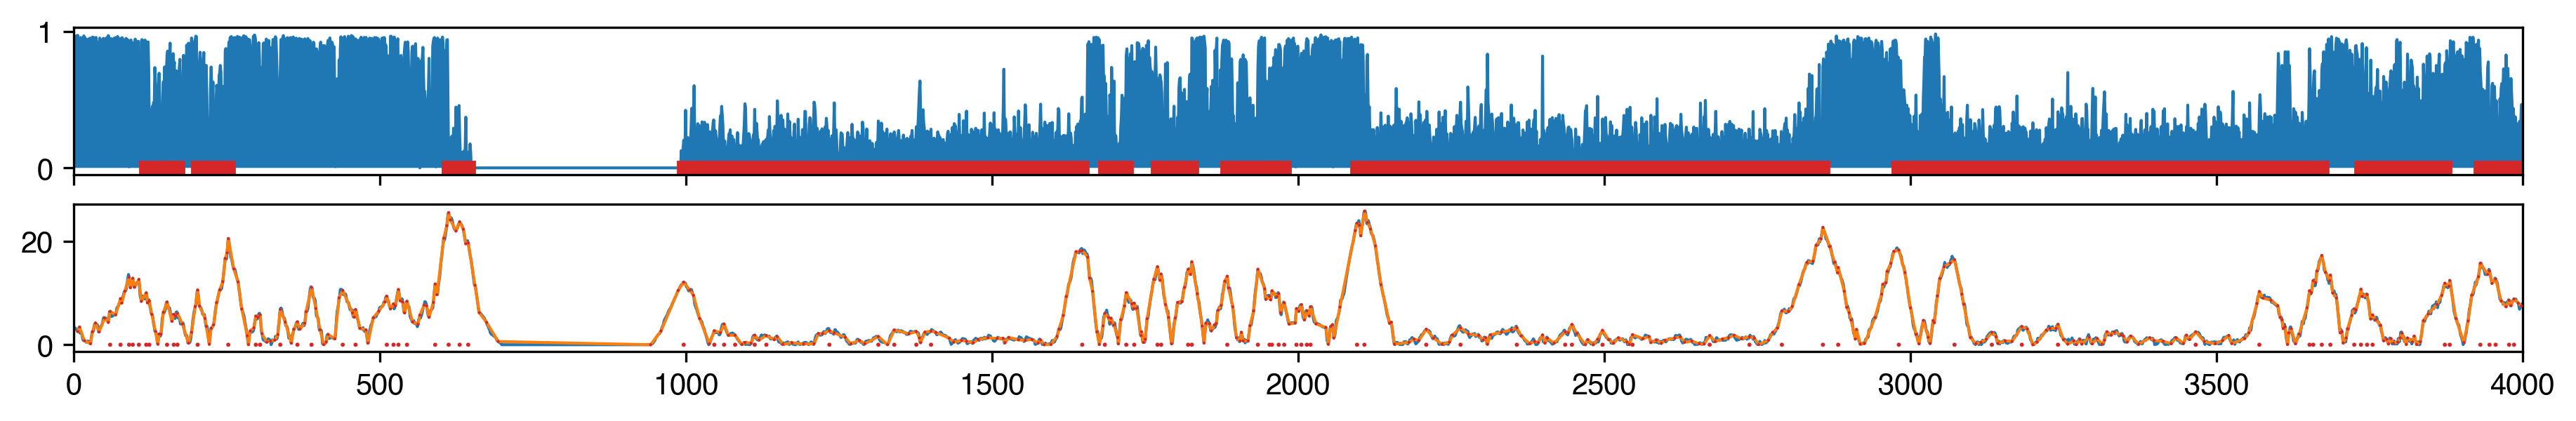

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(15,2), dpi=300, sharex='all')

ax = axes[0]
tmp = datachr[(start//res):(end//res)]  ## 0 is datachr[start//res]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, linewidth=1)
ax.set_xlim([0, tmp.shape[0]])
ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor='C0', interpolate=True)
# ax.scatter(x[tmp<0.8], np.zeros((tmp<0.8).sum()), c='C3', s=1, edgecolor='none', rasterized=True)
pmdtmp = (pmdchr.loc[(pmdchr['end']>start) & (pmdchr['start']<end), ['start', 'end']].values - start) // res
for xx,yy in pmdtmp:
    ax.plot([xx, yy], [0, 0], 'C3', linewidth=1)

ax = axes[1]
tmp = np.zeros(datachr.shape[0])
tmp[ws:(-ws+1)] = np.abs(diff) ## ws is diff[0], is diff between datachr[0:ws] and datachr[ws:2ws], 0->datachr[0]
tmp = tmp[(start//res):(end//res)]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, 'C0', linewidth=1)

regionfilter = np.logical_and((turn+ws)>=start//res, (turn+ws)<end//res) ## shape n_turn
turntmp = turn[regionfilter] ## position in diff, 0 -> datachr[ws]
ax.plot(turntmp - start//res + ws, diff[turntmp], 'C1', linewidth=1)

ax.scatter(turntmp - start//res + ws, diff[turntmp], c='C3', s=1, zorder=100, edgecolor='none', rasterized=True)

regionfilter = np.logical_and((localmax+ws)>=start//res, (localmax+ws)<end//res) ## shape n_turn
tmp = localmax[regionfilter]
ax.scatter(tmp - start//res + ws, np.zeros(tmp.shape), c='C3', s=2, edgecolor='none', rasterized=True)


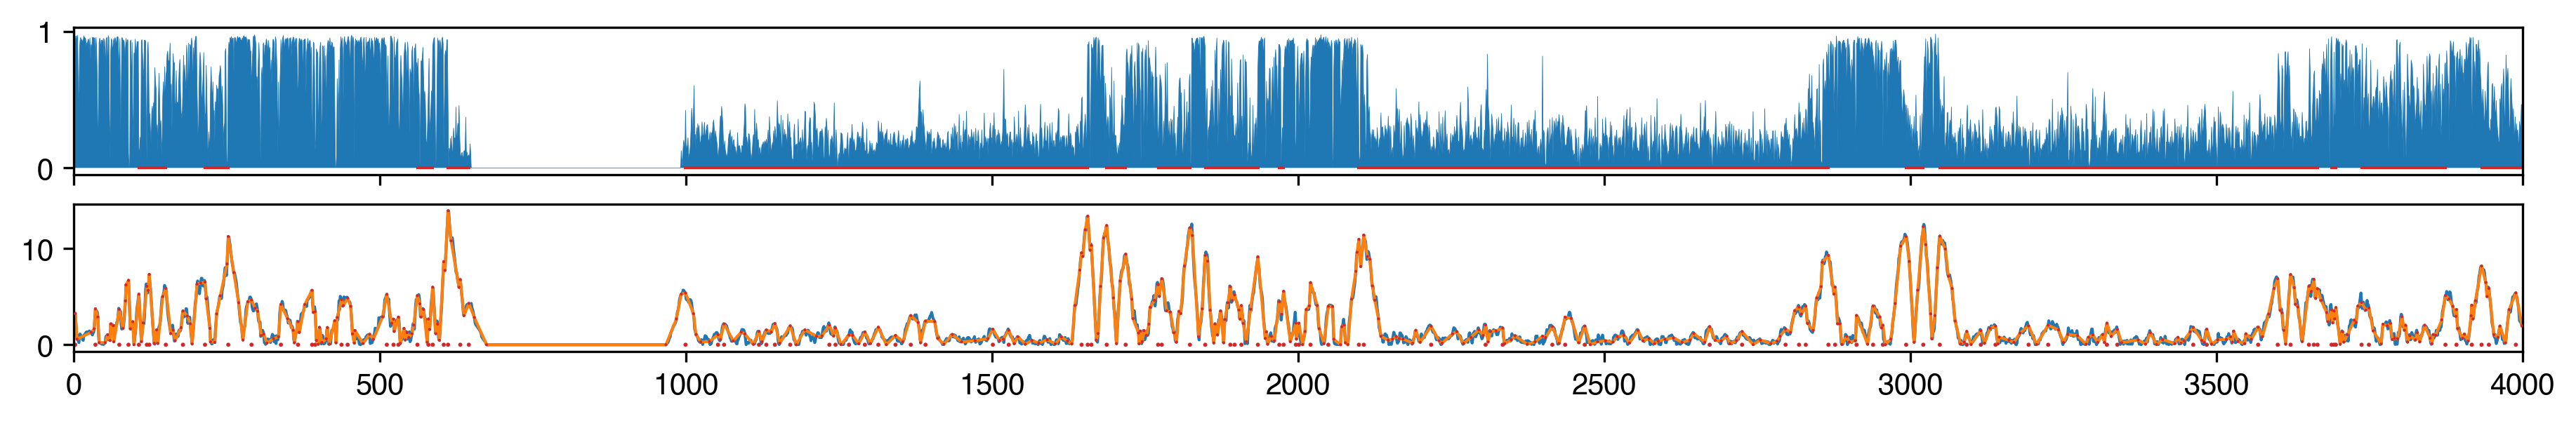

In [81]:
fig, axes = plt.subplots(2, 1, figsize=(15,2), dpi=300, sharex='all')

ax = axes[0]
tmp = datachr[(start//res):(end//res)]  ## 0 is datachr[start//res]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, linewidth=0.2)
ax.set_xlim([0, tmp.shape[0]])
ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor='C0', interpolate=True)
# ax.scatter(x[tmp<0.8], np.zeros((tmp<0.8).sum()), c='C3', s=1, edgecolor='none', rasterized=True)
pmdtmp = (pmdchr.loc[(pmdchr['end']>start) & (pmdchr['start']<end), ['start', 'end']].values - start) // res
for xx,yy in pmdtmp:
    ax.plot([xx, yy], [0, 0], 'C3', linewidth=1)

ax = axes[1]
tmp = np.zeros(datachr.shape[0])
tmp[ws:(-ws+1)] = np.abs(diff) ## ws is diff[0], is diff between datachr[0:ws] and datachr[ws:2ws], 0->datachr[0]
tmp = tmp[(start//res):(end//res)]
x = np.arange(tmp.shape[0])
ax.plot(x, tmp, 'C0', linewidth=1)

regionfilter = np.logical_and((turn+ws)>=start//res, (turn+ws)<end//res) ## shape n_turn
turntmp = turn[regionfilter] ## position in diff, 0 -> datachr[ws]
ax.plot(turntmp - start//res + ws, diff[turntmp], 'C1', linewidth=1)

ax.scatter(turntmp - start//res + ws, diff[turntmp], c='C3', s=1, zorder=100, edgecolor='none', rasterized=True)

regionfilter = np.logical_and((localmax+ws)>=start//res, (localmax+ws)<end//res) ## shape n_turn
tmp = localmax[regionfilter]
ax.scatter(tmp - start//res + ws, np.zeros(tmp.shape), c='C3', s=2, edgecolor='none', rasterized=True)
